In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import glob
import os
from waymo_open_dataset.protos import scenario_pb2


2026-04-14 17:09:40.790651: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-14 17:09:40.847255: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-14 17:09:41.129583: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/drivex/Ali/waymo_env/lib/python3.10/site-packages/nvidia/cudnn/lib:/home/drivex/Ali/waymo_en

In [2]:
file_paths = glob.glob('../data/raw/*.tfrecord*')
if not file_paths:
    print("Ensure your .tfrecord files are in the data/raw/ folder!")
else:
    dataset = tf.data.TFRecordDataset(file_paths[:1])
    for data in dataset.take(1):
        scenario = scenario_pb2.Scenario()
        scenario.ParseFromString(data.numpy())
    print(f"Loaded Scenario: {scenario.scenario_id}")



Loaded Scenario: f1bdf29eed41572c


2026-04-14 17:09:41.695135: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-04-14 17:09:41.709265: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-04-14 17:09:41.711424: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-04-14 17:09:41.712911: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuil

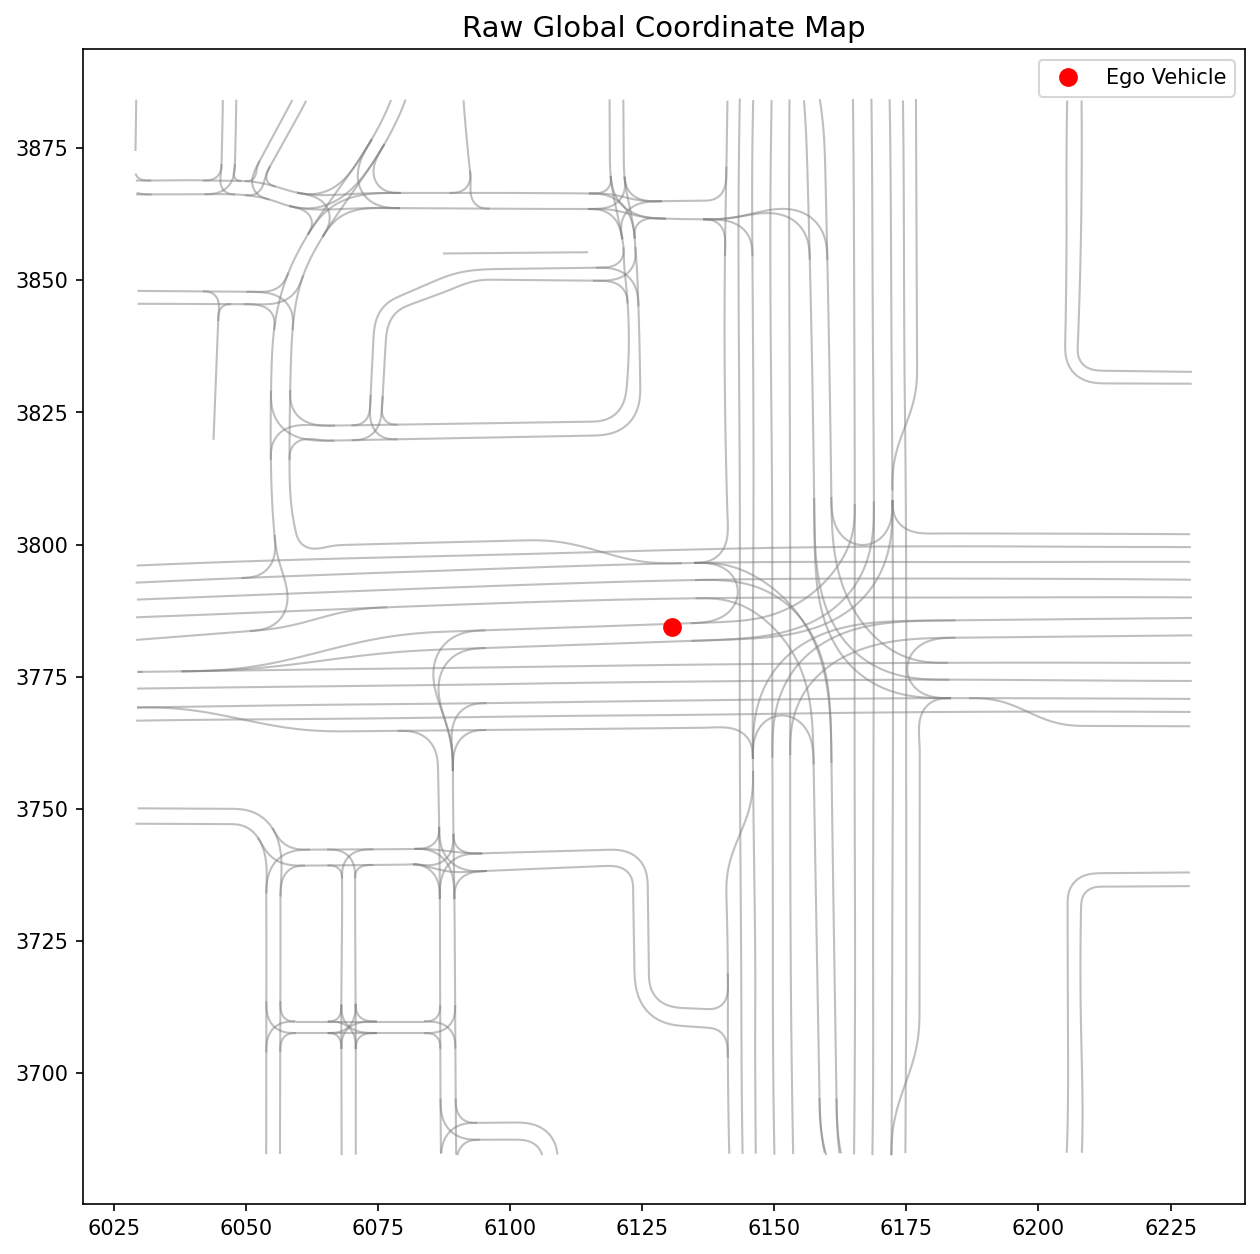

In [3]:
import matplotlib
matplotlib.use('Agg') # to work smoothly regarding remote Linux servers!
import matplotlib.pyplot as plt
import matplotlib.collections as mcoll
from IPython.display import Image, display

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_title(f"Raw Global Coordinate Map", fontsize=14)

lines = []
for feature in scenario.map_features:
    if feature.HasField('lane'):
        points = [(pt.x, pt.y) for pt in feature.lane.polyline]
        if points:
            lines.append(points)

line_collection = mcoll.LineCollection(lines, colors='gray', alpha=0.5, linewidths=1)
ax.add_collection(line_collection)

# Plot Ego Vehicle
ego_track = scenario.tracks[scenario.sdc_track_index]
ego_x = ego_track.states[10].center_x
ego_y = ego_track.states[10].center_y
ax.plot(ego_x, ego_y, 'ro', markersize=8, label="Ego Vehicle")

# Fix aspect ratio and limits so the map actually shows up
ax.autoscale()
ax.axis('equal')
ax.legend()

# Save and Display
plt.savefig('temp_map.png', dpi=150, bbox_inches='tight')
plt.close() # Free up server memory

display(Image('temp_map.png'))